# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [1]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [2]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


2026-04-23 16:49:48.179196: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [3]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 4. Load the Data


In [7]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt
    # 2. Load y_train from train/y_train.txt
    # 3. Load X_test from test/X_test.txt
    # 4. Load y_test from test/y_test.txt
    # 5. Convert the labels to zero-based class indices by subtracting 1
    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"))
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt")).astype(int) - 1

    X_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt"))
    y_test = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt")).astype(int) - 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

num_features = X_train.shape[1]
num_classes = len(np.unique(y_train))

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Number of input features:", num_features)
print("Number of classes:", num_classes)
 
label_counts = pd.Series(y_train).value_counts().sort_index()
summary_df = pd.DataFrame({
    "Class Index": range(num_classes),
    "Class Name": class_names,
    "Training Samples": label_counts.values
})
summary_df

    # <-- Enter your code here <--#
#raise NotImplementedError("Complete the data-loading function.")



# TODO: define num_features and num_classes
# <-- Enter your code here <--#


X_train shape: (7352, 561)
X_test shape : (2947, 561)
Number of input features: 561
Number of classes: 6


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 5. Quick Inspection


In [8]:
# TODO:
# Create a small summary table showing the class index, class name, and number of training samples.
label_counts = pd.Series(y_train).value_counts().sort_index()

dataset_summary = pd.DataFrame({
    "Class Index": list(range(num_classes)),
    "Class Name": class_names,
    "Training Samples": label_counts.values,
})

dataset_summary

# <-- Enter your code here <--#


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [10]:
def build_baseline_model(input_dim, num_classes):
    """Build and compile the baseline dense network for HAR classification.

    Architecture:
        Input(input_dim) -> Dense(256, relu) -> Dense(128, relu)
                         -> Dense(64, relu)  -> Dense(num_classes, softmax)
    """
    model = keras.Sequential([
        keras.layers.InputLayer(input_shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [11]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True,
    )
]

history = baseline_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=2,
)


Epoch 1/40
92/92 - 2s - loss: 0.4846 - accuracy: 0.8012 - val_loss: 0.2626 - val_accuracy: 0.8892 - 2s/epoch - 17ms/step
Epoch 2/40
92/92 - 0s - loss: 0.1649 - accuracy: 0.9354 - val_loss: 0.1605 - val_accuracy: 0.9293 - 402ms/epoch - 4ms/step
Epoch 3/40
92/92 - 0s - loss: 0.1110 - accuracy: 0.9558 - val_loss: 0.3800 - val_accuracy: 0.8912 - 389ms/epoch - 4ms/step
Epoch 4/40
92/92 - 0s - loss: 0.0902 - accuracy: 0.9646 - val_loss: 0.1858 - val_accuracy: 0.9327 - 365ms/epoch - 4ms/step
Epoch 5/40
92/92 - 0s - loss: 0.0951 - accuracy: 0.9623 - val_loss: 0.2012 - val_accuracy: 0.9245 - 356ms/epoch - 4ms/step
Epoch 6/40
92/92 - 0s - loss: 0.0655 - accuracy: 0.9762 - val_loss: 0.2735 - val_accuracy: 0.9225 - 385ms/epoch - 4ms/step
Epoch 7/40
92/92 - 0s - loss: 0.0640 - accuracy: 0.9760 - val_loss: 0.1527 - val_accuracy: 0.9395 - 380ms/epoch - 4ms/step
Epoch 8/40
92/92 - 0s - loss: 0.0581 - accuracy: 0.9799 - val_loss: 0.1760 - val_accuracy: 0.9395 - 379ms/epoch - 4ms/step
Epoch 9/40
92/92 -

### Training Curves


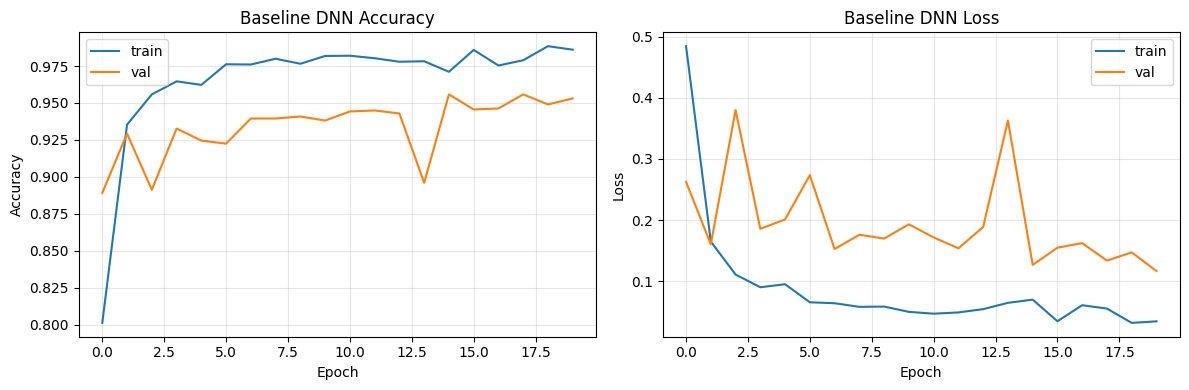

In [12]:
# TODO:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

# <-- Enter your code here <--#
# Plot training/validation accuracy and loss side by side.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="val")
axes[0].set_title("Baseline DNN Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="val")
axes[1].set_title("Baseline DNN Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Evaluate the Baseline Keras Model


Baseline Keras model test accuracy: 0.9413

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.94      0.98      0.96       496
  WALKING_UPSTAIRS       0.94      0.92      0.93       471
WALKING_DOWNSTAIRS       0.94      0.93      0.94       420
           SITTING       0.96      0.85      0.90       491
          STANDING       0.87      0.97      0.92       532
            LAYING       1.00      0.99      0.99       537

          accuracy                           0.94      2947
         macro avg       0.94      0.94      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



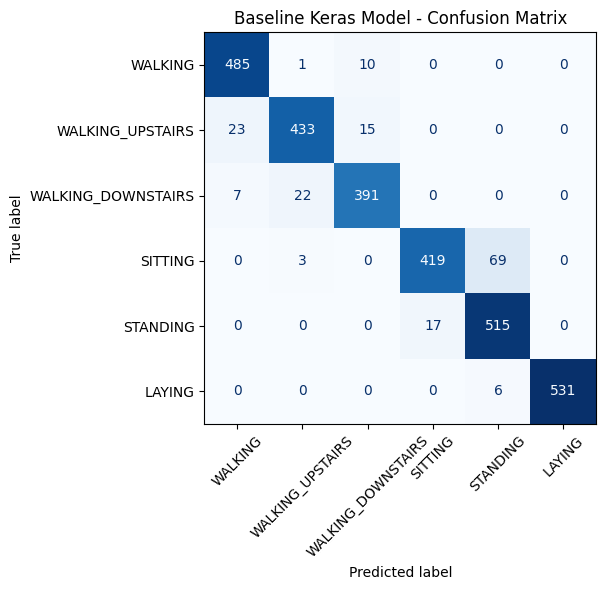

In [13]:
# TODO:
# 1. Obtain predicted probabilities on X_test
# 2. Convert them to class predictions using argmax
# 3. Compute test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

# <-- Enter your code here <--#
# 1. Probabilities on the test set
y_pred_proba_baseline = baseline_model.predict(X_test, verbose=0)

# 2. Argmax -> class predictions
y_pred_baseline = np.argmax(y_pred_proba_baseline, axis=1)

# 3. Test accuracy
baseline_test_acc = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline Keras model test accuracy: {baseline_test_acc:.4f}")

# 4. Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline, target_names=class_names))

# 5. Confusion matrix
cm_baseline = confusion_matrix(y_test, y_pred_baseline)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm_baseline, display_labels=class_names).plot(
    ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False
)
ax.set_title("Baseline Keras Model - Confusion Matrix")
plt.tight_layout()
plt.show()


## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [14]:
def save_binary_model(model_content, filename):
    """Write TFLite bytes to disk and return the size in KB."""
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB


def representative_dataset_gen():
    """Yield 300 representative float32 samples from X_train for int8 calibration."""
    rng = np.random.default_rng(SEED)
    idx = rng.choice(len(X_train), size=300, replace=False)
    for i in idx:
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]


def evaluate_tflite_model(tflite_model, X, y_true):
    """Run inference sample-by-sample on a TFLite model. Returns (accuracy, predictions)."""
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    input_dtype = input_details["dtype"]
    output_dtype = output_details["dtype"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # Quantize the input only when the model expects int8/uint8 input.
        if input_dtype in (np.int8, np.uint8):
            x = x / input_scale + input_zero_point
            x = np.round(x).astype(input_dtype)
        else:
            # Float model: cast to the required float dtype (float32 or float16)
            x = x.astype(input_dtype)

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # Dequantize the output if it is quantized.
        if output_dtype in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred


def convert_to_tflite_fp32(model):
    """Plain float32 TFLite conversion (no optimizations)."""
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()


def convert_to_tflite_dynamic_range(model):
    """Dynamic range quantization: weights -> int8, activations stay float."""
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()


def convert_to_tflite_float16(model):
    """Float16 quantization: weights stored as fp16."""
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()


def convert_to_tflite_int8(model):
    """Full integer (int8) quantization using a representative dataset."""
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()



## 9. Post-Training Quantization (PTQ)


In [15]:
# TODO:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.

# <-- Enter your code here <--#
# Convert the baseline model into four TFLite flavors, save them, and evaluate each.
tflite_results = {}  # name -> dict with size_kb, accuracy, model_bytes, y_pred, filename

conversion_fns = {
    "fp32":          convert_to_tflite_fp32,
    "dynamic_range": convert_to_tflite_dynamic_range,
    "float16":       convert_to_tflite_float16,
    "int8":          convert_to_tflite_int8,
}

for name, fn in conversion_fns.items():
    print(f"\n--- Converting baseline -> TFLite ({name}) ---")
    tflite_bytes = fn(baseline_model)
    filename = f"baseline_{name}.tflite"
    size_kb = save_binary_model(tflite_bytes, filename)
    acc, y_pred = evaluate_tflite_model(tflite_bytes, X_test, y_test)
    tflite_results[name] = {
        "size_kb": size_kb,
        "accuracy": acc,
        "model_bytes": tflite_bytes,
        "y_pred": y_pred,
        "filename": filename,
    }
    print(f"  {name:<14s}  size = {size_kb:8.2f} KB   test acc = {acc:.4f}")



--- Converting baseline -> TFLite (fp32) ---
INFO:tensorflow:Assets written to: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmphre1fe2u/assets


INFO:tensorflow:Assets written to: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmphre1fe2u/assets
2026-04-23 21:41:09.708277: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 21:41:09.708626: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 21:41:09.710146: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmphre1fe2u
2026-04-23 21:41:09.712881: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 21:41:09.712936: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmphre1fe2u
2026-04-23 21:41:09.720915: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-04-23 21:41:09.723557: I tensorflow/cc/saved_model/load

  fp32            size =   726.72 KB   test acc = 0.9413

--- Converting baseline -> TFLite (dynamic_range) ---
INFO:tensorflow:Assets written to: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmpra_uhs87/assets


INFO:tensorflow:Assets written to: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmpra_uhs87/assets
2026-04-23 21:41:12.671150: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 21:41:12.671178: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 21:41:12.671595: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmpra_uhs87
2026-04-23 21:41:12.675023: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 21:41:12.675058: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmpra_uhs87
2026-04-23 21:41:12.682741: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 21:41:12.861292: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

  dynamic_range   size =   186.11 KB   test acc = 0.9410

--- Converting baseline -> TFLite (float16) ---
INFO:tensorflow:Assets written to: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmpi7cw8uxz/assets


INFO:tensorflow:Assets written to: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmpi7cw8uxz/assets
2026-04-23 21:41:16.207341: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 21:41:16.207370: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 21:41:16.207782: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmpi7cw8uxz
2026-04-23 21:41:16.214760: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 21:41:16.214790: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmpi7cw8uxz
2026-04-23 21:41:16.221777: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 21:41:16.387451: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

  float16         size =   365.71 KB   test acc = 0.9413

--- Converting baseline -> TFLite (int8) ---
INFO:tensorflow:Assets written to: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmpj5jo0i77/assets


INFO:tensorflow:Assets written to: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmpj5jo0i77/assets
/Users/phinapenteriani/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-23 21:41:19.068166: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 21:41:19.068190: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 21:41:19.068896: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmpj5jo0i77
2026-04-23 21:41:19.071376: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 21:41:19.071405: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/p8/hgvq1

  int8            size =   185.34 KB   test acc = 0.9420


## 10. PTQ Comparison: Accuracy and Model Size


In [16]:
# Build a comparison DataFrame for the four PTQ models.
ptq_comparison = pd.DataFrame([
    {
        "Model Family": "Baseline DNN",
        "Format": name,
        "Test Accuracy": tflite_results[name]["accuracy"],
        "Model Size (KB)": tflite_results[name]["size_kb"],
    }
    for name in ["fp32", "dynamic_range", "float16", "int8"]
])

ptq_comparison



,Model Family,Format,Test Accuracy,Model Size (KB)
0,Baseline DNN,fp32,0.941296,726.718750
1,Baseline DNN,dynamic_range,0.940957,186.109375
2,Baseline DNN,float16,0.941296,365.710938
3,Baseline DNN,int8,0.941975,185.335938


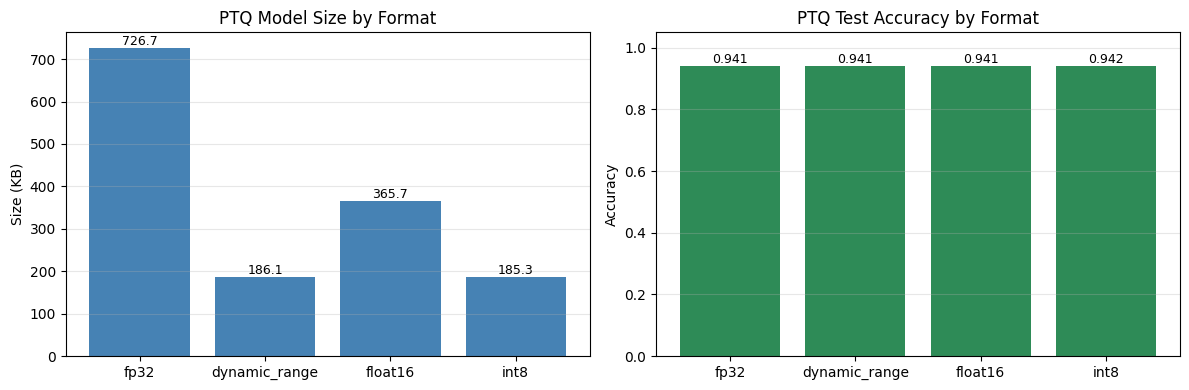

In [17]:
# TODO:
# Create one bar plot for model size and another for test accuracy.

# <-- Enter your code here <--#
# Bar plots: model size (KB) and test accuracy across the four PTQ formats.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(ptq_comparison["Format"], ptq_comparison["Model Size (KB)"], color="steelblue")
axes[0].set_title("PTQ Model Size by Format")
axes[0].set_ylabel("Size (KB)")
axes[0].grid(True, axis="y", alpha=0.3)
for i, v in enumerate(ptq_comparison["Model Size (KB)"]):
    axes[0].text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)

axes[1].bar(ptq_comparison["Format"], ptq_comparison["Test Accuracy"], color="seagreen")
axes[1].set_title("PTQ Test Accuracy by Format")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, axis="y", alpha=0.3)
for i, v in enumerate(ptq_comparison["Test Accuracy"]):
    axes[1].text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

### Confusion Matrix for the PTQ Int8 Model


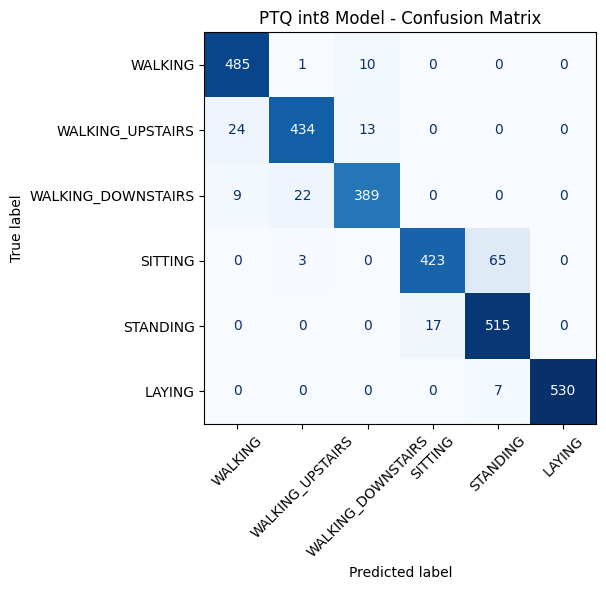


Classification Report (PTQ int8):
                    precision    recall  f1-score   support

           WALKING       0.94      0.98      0.96       496
  WALKING_UPSTAIRS       0.94      0.92      0.93       471
WALKING_DOWNSTAIRS       0.94      0.93      0.94       420
           SITTING       0.96      0.86      0.91       491
          STANDING       0.88      0.97      0.92       532
            LAYING       1.00      0.99      0.99       537

          accuracy                           0.94      2947
         macro avg       0.94      0.94      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



In [18]:
# TODO:
# Plot the confusion matrix for the PTQ int8 model.
# Print the classification report for the PTQ int8 model.

# <-- Enter your code here <--#
# Confusion matrix and classification report for the PTQ int8 model.
y_pred_ptq_int8 = tflite_results["int8"]["y_pred"]

cm_ptq_int8 = confusion_matrix(y_test, y_pred_ptq_int8)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm_ptq_int8, display_labels=class_names).plot(
    ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False
)
ax.set_title("PTQ int8 Model - Confusion Matrix")
plt.tight_layout()
plt.show()

print("\nClassification Report (PTQ int8):")
print(classification_report(y_test, y_pred_ptq_int8, target_names=class_names))


## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [19]:
# TODO:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#
# Wrap the trained baseline with TF-MOT quantization-aware training layers.
quantize_model = tfmot.quantization.keras.quantize_model

qat_model = quantize_model(baseline_model)

# quantize_model removes the optimizer; we must recompile.
qat_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

qat_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 quantize_layer (QuantizeLa  (None, 561)               3         
 yer)                                                            
                                                                 
 quant_dense (QuantizeWrapp  (None, 256)               143877    
 erV2)                                                           
                                                                 
 quant_dense_1 (QuantizeWra  (None, 128)               32901     
 pperV2)                                                         
                                                                 
 quant_dense_2 (QuantizeWra  (None, 64)                8261      
 pperV2)                                                         
                                                                 
 quant_dense_3 (QuantizeWra  (None, 6)                 3

### Fine-Tune the QAT Model


In [20]:
# TODO:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

# <-- Enter your code here <--#
# Fine-tune the QAT model for 8 epochs.
qat_history = qat_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64,
    verbose=2,
)


Epoch 1/8
92/92 - 2s - loss: 0.0332 - accuracy: 0.9889 - val_loss: 0.1250 - val_accuracy: 0.9579 - 2s/epoch - 26ms/step
Epoch 2/8
92/92 - 1s - loss: 0.0298 - accuracy: 0.9900 - val_loss: 0.1390 - val_accuracy: 0.9504 - 524ms/epoch - 6ms/step
Epoch 3/8
92/92 - 1s - loss: 0.0292 - accuracy: 0.9900 - val_loss: 0.1255 - val_accuracy: 0.9579 - 521ms/epoch - 6ms/step
Epoch 4/8
92/92 - 0s - loss: 0.0270 - accuracy: 0.9903 - val_loss: 0.1232 - val_accuracy: 0.9558 - 500ms/epoch - 5ms/step
Epoch 5/8
92/92 - 1s - loss: 0.0262 - accuracy: 0.9912 - val_loss: 0.1555 - val_accuracy: 0.9545 - 537ms/epoch - 6ms/step
Epoch 6/8
92/92 - 1s - loss: 0.0278 - accuracy: 0.9891 - val_loss: 0.1605 - val_accuracy: 0.9524 - 618ms/epoch - 7ms/step
Epoch 7/8
92/92 - 1s - loss: 0.0256 - accuracy: 0.9913 - val_loss: 0.1332 - val_accuracy: 0.9572 - 705ms/epoch - 8ms/step
Epoch 8/8
92/92 - 1s - loss: 0.0257 - accuracy: 0.9915 - val_loss: 0.1313 - val_accuracy: 0.9579 - 573ms/epoch - 6ms/step


### Evaluate the QAT Keras Model


In [21]:
# TODO:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.

# <-- Enter your code here <--#
# Evaluate the QAT Keras model on the test set.
y_pred_proba_qat = qat_model.predict(X_test, verbose=0)
y_pred_qat_keras = np.argmax(y_pred_proba_qat, axis=1)

qat_keras_acc = accuracy_score(y_test, y_pred_qat_keras)
print(f"QAT Keras model test accuracy: {qat_keras_acc:.4f}")

print("\nClassification Report (QAT Keras):")
print(classification_report(y_test, y_pred_qat_keras, target_names=class_names))


QAT Keras model test accuracy: 0.9379

Classification Report (QAT Keras):
                    precision    recall  f1-score   support

           WALKING       0.95      0.97      0.96       496
  WALKING_UPSTAIRS       0.94      0.92      0.93       471
WALKING_DOWNSTAIRS       0.94      0.94      0.94       420
           SITTING       0.94      0.87      0.91       491
          STANDING       0.87      0.95      0.91       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.94      2947
         macro avg       0.94      0.94      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [22]:
# TODO:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

# <-- Enter your code here <--#
qat_converter = tf.lite.TFLiteConverter.from_keras_model(qat_model)
qat_converter.optimizations = [tf.lite.Optimize.DEFAULT]
qat_converter.representative_dataset = representative_dataset_gen
qat_converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
qat_converter.inference_input_type = tf.int8
qat_converter.inference_output_type = tf.int8

qat_tflite_bytes = qat_converter.convert()
qat_filename = "qat_int8.tflite"
qat_size_kb = save_binary_model(qat_tflite_bytes, qat_filename)

qat_int8_acc, y_pred_qat_int8 = evaluate_tflite_model(qat_tflite_bytes, X_test, y_test)

print(f"QAT int8 TFLite model size: {qat_size_kb:.2f} KB")
print(f"QAT int8 TFLite test accuracy: {qat_int8_acc:.4f}")


INFO:tensorflow:Assets written to: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmpaghiqjfg/assets


INFO:tensorflow:Assets written to: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmpaghiqjfg/assets


QAT int8 TFLite model size: 185.70 KB
QAT int8 TFLite test accuracy: 0.9379


/Users/phinapenteriani/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-23 21:41:32.597889: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 21:41:32.597910: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 21:41:32.598145: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmpaghiqjfg
2026-04-23 21:41:32.601925: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 21:41:32.601941: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/p8/hgvq1dqj20ncmtw6s7ys78f80000gn/T/tmpaghiqjfg
2026-04-23 21:41:32.612658: I tensorflow/cc/saved_model/loader.

## 12. PTQ Int8 vs QAT Int8


In [23]:
# TODO:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
# Compare PTQ int8 vs QAT int8 in a small DataFrame.
int8_comparison = pd.DataFrame([
    {
        "Model": "PTQ int8",
        "Test Accuracy": tflite_results["int8"]["accuracy"],
        "Model Size (KB)": tflite_results["int8"]["size_kb"],
    },
    {
        "Model": "QAT int8",
        "Test Accuracy": qat_int8_acc,
        "Model Size (KB)": qat_size_kb,
    },
])

int8_comparison


,Model,Test Accuracy,Model Size (KB)
0,PTQ int8,0.941975,185.335938
1,QAT int8,0.937903,185.695312


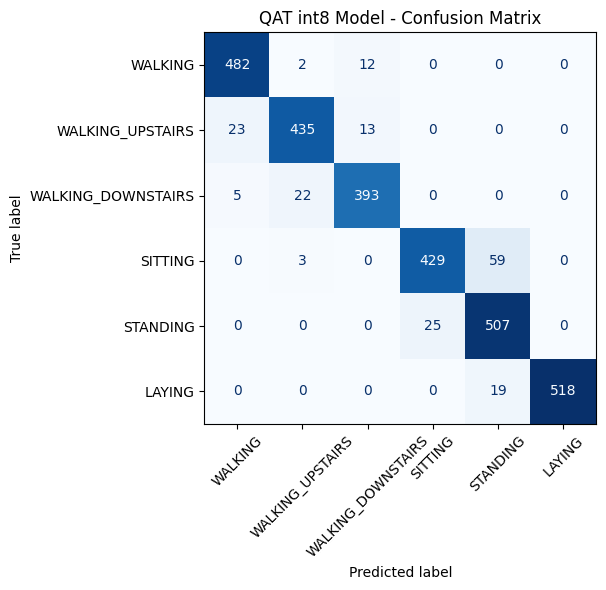


Classification Report (QAT int8):
                    precision    recall  f1-score   support

           WALKING       0.95      0.97      0.96       496
  WALKING_UPSTAIRS       0.94      0.92      0.93       471
WALKING_DOWNSTAIRS       0.94      0.94      0.94       420
           SITTING       0.94      0.87      0.91       491
          STANDING       0.87      0.95      0.91       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.94      2947
         macro avg       0.94      0.94      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



In [24]:
# TODO:
# Plot the confusion matrix for the QAT int8 model.

# <-- Enter your code here <--#
# Confusion matrix and report for the QAT int8 model.
cm_qat_int8 = confusion_matrix(y_test, y_pred_qat_int8)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm_qat_int8, display_labels=class_names).plot(
    ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False
)
ax.set_title("QAT int8 Model - Confusion Matrix")
plt.tight_layout()
plt.show()

print("\nClassification Report (QAT int8):")
print(classification_report(y_test, y_pred_qat_int8, target_names=class_names))

## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size? The int8 model was smallest at 185.34 KB, followed very closely by dynamic range at 186.11 KB. Both are roughly 3.9× smaller than the FP32 TFLite baseline (726.72 KB) because every 32-bit weight is replaced by an 8-bit integer.
2. Which quantization method gave the best accuracy among the TensorFlow Lite models? Surprisingly, int8 was the most accurate at 0.9420 — slightly higher than FP32 and float16, which tied at 0.9413. Dynamic range came in lowest at 0.9410. The spread is tiny (about 0.07 percentage points, or roughly 2 samples out of 2,947), so practically all four are statistically equivalent.
3. Did QAT improve the final int8 model compared with PTQ int8 ?No — PTQ int8 actually outperformed QAT int8 on your run (0.9420 vs 0.9379, a drop of about 0.4 percentage points or ~12 more misclassifications). Model sizes were essentially identical (185.34 KB vs 185.70 KB). This is a legitimate and useful finding: QAT is not guaranteed to help, especially when the baseline PTQ already performs at near-FP32 levels.
4. Why is this dataset a good fit for a DNN-based TinyML workflow? UCI HAR provides pre-extracted, low-dimensional numerical features (561 floats) derived from smartphone IMU signals, with only 6 reasonably balanced classes. The results confirm this is a great TinyML fit: a compact dense network hits ~94% test accuracy at under 186 KB in int8 form — small enough to deploy on Cortex-M microcontrollers with room to spare for the runtime
5. If you were deploying this model on a resource-constrained device, which version would you choose and why? I'd choose PTQ int8 based on my specific results. It gave the highest accuracy (0.9420), the smallest footprint (185.34 KB), integer-only arithmetic for fast inference on CMSIS-NN / Cortex-M kernels


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
